Data preparation for comparison with Johansson et al., 2013


In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 



**Winsconsin Breast Cancer**

In [21]:


dataset = "breastW"

# fetch wisconsin dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [22]:
X.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')

In [23]:
std = StandardScaler()
X_norm = std.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
db = pd.concat((X_norm,y), axis = 1)

#db = pd.concat((X,y), axis = 1)
db["Diagnosis"].replace({"M": 1, "B":0}, inplace = True)

/var/folders/9h/svsvtj351111fqd57806yp6m0000gn/T/ipykernel_17101/4283193845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["Diagnosis"].replace({"M": 1, "B":0}, inplace = True)
/var/folders/9h/svsvtj351111fqd57806yp6m0000gn/T/ipykernel_17101/4283193845.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcastin

In [24]:

data_train_cal, data_ts = train_test_split(db, test_size=int(len(db)/4), random_state=102)

data_tr, data_cal = train_test_split(data_train_cal, test_size=int(len(db)/4), random_state=102)


In [25]:
os.makedirs(f"data/{dataset}/", exist_ok = True)
data_tr.to_excel(f"data/{dataset}/proper.xlsx", index = False)
data_cal.to_excel(f"data/{dataset}/calibration.xlsx", index = False)
data_ts.to_excel(f"data/{dataset}/test.xlsx", index = False)

In [15]:
data_tr.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'Diagnosis'],
      dtype='object')

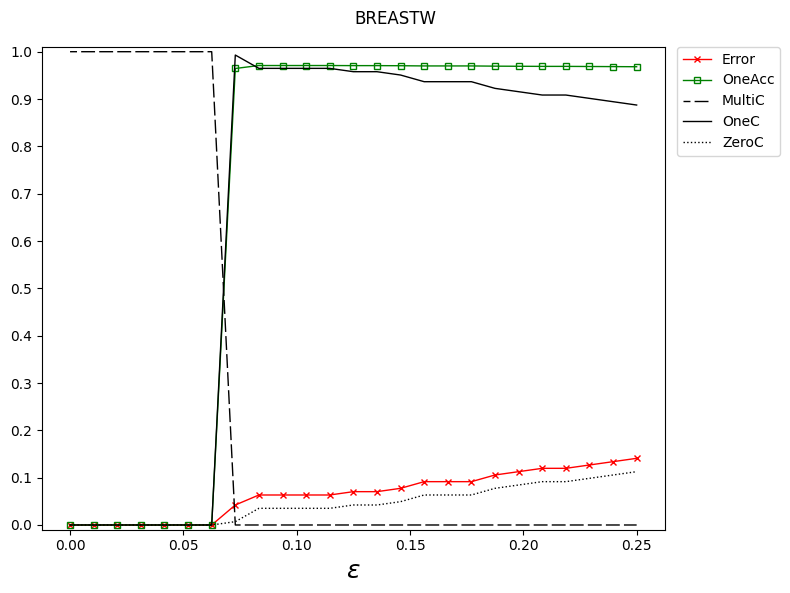

In [ ]:


# Wisconsin breast cancer - plot as Fig.2 
resfolder = 'test_dt_GIoU_PrunOff/'#"/Users/saranarteni/OneDrive - CNR/Conformal Predictors/CONFIDERAI_newcode/results_rev_paper_20240325/"
datasetlist=['breastW']
save_plot = False
#csr = pd.read_csv(resfolder+"metrics_CSR_rounded.csv")

metrics_results=[]
for i,dataset in enumerate(datasetlist):
    res = pd.read_csv(resfolder+"metrics_"+dataset+".csv")
    fig, ax = plt.subplots(1,1, figsize = (8,6))
    
    ax.plot(res["epsilon"],res["avgErr"],'red', linewidth=1, linestyle = "-", marker='x', markersize=5, label = "Error")
    
    ax.plot(res["epsilon"],res["oneAcc"],'green', linewidth=1,marker='s', markersize=5, markerfacecolor = "none", linestyle = '-', label = "OneAcc")
    ax.plot(res["epsilon"],res["avgDouble"],'black', linewidth=1,linestyle = (5, (10, 3)), label = "MultiC")
    ax.plot(res["epsilon"],res["avgSingle"],'black', linewidth=1,linestyle = '-', label = "OneC")
    ax.plot(res["epsilon"],res["avgEmpty"],'black', linestyle = "dotted", linewidth=1, label = "ZeroC")
    
   
    ax.set_xlabel(r"$\varepsilon$", fontsize = 18)
    ax.set_ylim([-0.01,1.01])
    ax.set_yticks(np.arange(0,1.1, 0.1))
    #ax.set_xlim([0,1])
    ax.set_xticks(np.arange(0,0.30, 0.05))
    fig.suptitle(dataset.upper())



    #ax.grid(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f"{resfolder}/{dataset}_metrics.png", dpi = 200, bbox_inches = "tight")
    plt.show()

**Pima DIABETES**

In [35]:
dataset = "diabetes"

db = pd.read_csv("data/diabetes/diabetes.csv")

db

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# standardizzare!

data_train_cal, data_ts = train_test_split(db, test_size=int(len(db)/4), random_state=102)
data_tr, data_cal = train_test_split(data_train_cal, test_size=int(len(db)/4), random_state=102)
os.makedirs(f"data/{dataset}/", exist_ok = True)
data_tr.to_excel(f"data/{dataset}/proper.xlsx", index = False)
data_cal.to_excel(f"data/{dataset}/calibration.xlsx", index = False)
data_ts.to_excel(f"data/{dataset}/test.xlsx", index = False)

In [32]:
db.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

**Indian Liver**

In [10]:
dataset = "liver"
# fetch dataset 
ilpd_indian_liver_patient_dataset = fetch_ucirepo(id=225) 
  
# data (as pandas dataframes) 
X = ilpd_indian_liver_patient_dataset.data.features 
y = ilpd_indian_liver_patient_dataset.data.targets 


In [18]:
X.drop(["Gender"], axis =1, inplace = True)

/var/folders/9h/svsvtj351111fqd57806yp6m0000gn/T/ipykernel_17101/2572604343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(["Gender"], axis =1, inplace = True)


In [19]:

std = StandardScaler()
X_norm = std.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
db = pd.concat((X_norm,y), axis = 1)

#db = pd.concat((X,y), axis = 1)

db["Selector"].replace({1: 0, 2: 1}, inplace = True)
data_train_cal, data_ts = train_test_split(db, test_size=int(len(db)/4), random_state=102)

data_tr, data_cal = train_test_split(data_train_cal, test_size=int(len(db)/4), random_state=102)

os.makedirs(f"data/{dataset}/", exist_ok = True)
data_tr.to_excel(f"data/{dataset}/proper.xlsx", index = False)
data_cal.to_excel(f"data/{dataset}/calibration.xlsx", index = False)
data_ts.to_excel(f"data/{dataset}/test.xlsx", index = False)


/var/folders/9h/svsvtj351111fqd57806yp6m0000gn/T/ipykernel_17101/2618328618.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["Selector"].replace({1: 0, 2: 1}, inplace = True)


In [20]:
db.columns

Index(['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio',
       'Selector'],
      dtype='object')

**Dataset da OpenML**

In [3]:
import openml

# List all datasets and their properties
#openml.datasets.list_datasets(output_format="dataframe")
dataset = "spambase"
# Get dataset by name
data = openml.datasets.get_dataset(dataset)

# Get the data itself as a dataframe (or otherwise)
X, y, _, _ = data.get_data(dataset_format="dataframe")
y = X.iloc[:,-1]
X = X.iloc[:,:-1]
std = StandardScaler()
X_norm = std.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)
db = pd.concat((X_norm,y), axis = 1)
#kc2: db["problems"].replace({"yes": 1, "no":0}, inplace = True)
#db["class"].replace({"b": 1, "g":0}, inplace = True)
db

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724,1
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324,1
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733,1
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.672880,-0.165072,0.673183,-0.0469,-0.464314,0.781971,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,0.343917,-0.155198,-0.329912,-0.308355,-0.103048,-0.127640,-0.252336,-0.322110,0
4597,-0.342434,-0.165072,-0.556761,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,-0.514307,-0.155198,0.102907,-0.308355,-0.103048,-0.114623,-0.247205,-0.444165,0
4598,0.640128,-0.165072,0.038373,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,0.260533,2.141746,-0.155198,-0.329912,-0.308355,-0.103048,-0.119382,-0.236941,-0.272628,0
4599,2.801763,-0.165072,-0.556761,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,-0.303450,-0.155198,-0.329912,-0.308355,-0.103048,-0.127483,-0.242073,-0.338604,0


In [4]:
data_train_cal, data_ts = train_test_split(db, test_size=int(len(db)/4), random_state=102)

data_tr, data_cal = train_test_split(data_train_cal, test_size=int(len(db)/4), random_state=102)

os.makedirs(f"data/{dataset}/", exist_ok = True)
data_tr.to_excel(f"data/{dataset}/proper.xlsx", index = False)
data_cal.to_excel(f"data/{dataset}/calibration.xlsx", index = False)
data_ts.to_excel(f"data/{dataset}/test.xlsx", index = False)


In [14]:
db.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


# Implementing another score function for comparison

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from dt_utils import *
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

datasetname = "breastW"
outputlabel = "Diagnosis"

train =  pd.read_excel(f"data/{datasetname}/proper.xlsx")
calib = pd.read_excel(f"data/{datasetname}/calibration.xlsx")
test = pd.read_excel(f"data/{datasetname}/test.xlsx")
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]
X_calib = calib.iloc[:, :-1]
y_calib = calib.iloc[:, -1]
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

'''
def standardize_data(X):
    std = StandardScaler()
    X_norm = std.fit_transform(X)
    X_norm = pd.DataFrame(X_norm, columns=X.columns)
    return X_norm

X_train = standardize_data(X_train)
X_calib = standardize_data(X_calib)
X_test = standardize_data(X_test)
'''

model = DecisionTreeClassifier(random_state=10)

model = model.fit(X_train,y_train)
y_pred_ts = model.predict(X_test)
print("Decision Tree base performance")
acc, f1, recall, precision = accuracy_score(y_test, y_pred_ts), f1_score(y_test, y_pred_ts), recall_score(y_test, y_pred_ts), precision_score(y_test, y_pred_ts)
print(f"Accuracy = {acc}, F1 score = {f1}, Recall = {recall}, Precision = {precision}")

rules, _ = ExtractRulesFromDT(model, list(model.feature_names_in_), [0,1], outputlabel)
for rule in rules:
    print(rule)

Decision Tree base performance
Accuracy = 0.9577464788732394, F1 score = 0.9387755102040817, Recall = 0.92, Precision = 0.9583333333333334
RULE 1: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND area2 <= 32.985 AND smoothness3 <= 0.191 AND radius3 <= 16.515 THEN Diagnosis in 0
RULE 2: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND area2 > 32.985 AND texture1 <= 21.435 AND symmetry3 > 0.204 THEN Diagnosis in 0
RULE 3: IF area3 > 874.85 AND texture3 <= 20.45 AND area2 <= 36.29 THEN Diagnosis in 0
RULE 4: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND area2 <= 32.985 AND smoothness3 <= 0.191 AND radius3 > 16.515 AND symmetry1 > 0.172 THEN Diagnosis in 0
RULE 5: IF area3 <= 874.85 AND concave_points3 > 0.153 AND texture3 <= 23.47 THEN Diagnosis in 0
RULE 6: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND area2 > 32.985 AND texture1 > 21.435 AND concave_points2 <= 0.013 THEN Diagnosis in 0
RULE 7: IF area3 > 874.85 AND texture3 > 20.45 AND concavity3 <= 0.18 AND smoothness

In [2]:
importances = model.feature_importances_
fnames = model.feature_names_in_
max_value = np.sort(importances)[-1]
max_value2 = np.sort(importances)[-2]
top2_idx = [int(np.squeeze(np.where(importances == max_value))),int(np.squeeze(np.where(importances == max_value2)))]
print(fnames[top2_idx])

['area3' 'concave_points3']


In [3]:
# TODO: riaddestrare in 2D sulle prime 2 variabili
model = DecisionTreeClassifier(random_state=10)
model = model.fit(X_train.iloc[:,top2_idx],y_train)
y_pred_ts = model.predict(X_test.iloc[:,top2_idx])
print("Decision Tree base performance")
acc, f1, recall, precision = accuracy_score(y_test, y_pred_ts), f1_score(y_test, y_pred_ts), recall_score(y_test, y_pred_ts), precision_score(y_test, y_pred_ts)
print(f"Accuracy = {acc}, F1 score = {f1}, Recall = {recall}, Precision = {precision}")

rules, _ = ExtractRulesFromDT(model, list(model.feature_names_in_), [0,1], outputlabel)
for rule in rules:
    print(rule)
'''
open("data/breastW/breast_dt_rules_2d.csv","w")
for rule in rules:
    print(rule)
    with open("data/breastW/breast_dt_rules_2d.csv","a") as rulefile:
        #print("saving rules to file")
        rulefile.write(str(rule)+f", COVERING: {np.random.uniform(0, 1)}, ERROR: {np.random.uniform(0, 1)}\n")
'''

Decision Tree base performance
Accuracy = 0.9225352112676056, F1 score = 0.8910891089108911, Recall = 0.9, Precision = 0.8823529411764706
RULE 1: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND concave_points3 <= 0.136 AND area3 <= 693.2 AND area3 <= 552.45 THEN Diagnosis in 0
RULE 2: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND concave_points3 <= 0.136 AND area3 <= 693.2 AND area3 > 552.45 AND area3 > 553.65 THEN Diagnosis in 0
RULE 3: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND concave_points3 <= 0.136 AND area3 > 693.2 AND concave_points3 > 0.031 AND concave_points3 <= 0.117 THEN Diagnosis in 0
RULE 4: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND concave_points3 > 0.136 AND concave_points3 > 0.14 AND area3 > 521.05 AND concave_points3 <= 0.146 THEN Diagnosis in 0
RULE 5: IF area3 <= 874.85 AND concave_points3 <= 0.153 AND concave_points3 <= 0.136 AND area3 > 693.2 AND concave_points3 > 0.031 AND concave_points3 > 0.117 AND concave_points3 > 0.125 THEN Diagn

'\nopen("data/breastW/breast_dt_rules_2d.csv","w")\nfor rule in rules:\n    print(rule)\n    with open("data/breastW/breast_dt_rules_2d.csv","a") as rulefile:\n        #print("saving rules to file")\n        rulefile.write(str(rule)+f", COVERING: {np.random.uniform(0, 1)}, ERROR: {np.random.uniform(0, 1)}\n")\n'

In [4]:
def extract_rule_thresholds_from_df(file_path, df):
    """
    Extract thresholds for each rule in the format:
    [lower_X1, upper_X1, lower_X2, upper_X2]
    """
    df.rename({"area3": "X1", "concave_points3":"X2"}, axis = 1, inplace = True)

    # Regex supports >, >=, <, <=
    condition_pattern = re.compile(r'(X\d+)\s*(<=|>=|<|>)\s*([-+]?\d*\.?\d+)')
    
    rule_thresholds = []

    # Dataset min/max
    data_min = df.min().to_dict()
    data_max = df.max().to_dict()

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith("RULE"):
                continue

            # Start with dataset-wide bounds
            lower = {var: data_min[var] for var in data_min}
            upper = {var: data_max[var] for var in data_max}

            # Extract all feature conditions
            matches = condition_pattern.findall(line)

            for var, op, value in matches:
                value = float(value)

                if op in ('>', '>='):
                    # increase lower bound
                    lower[var] = max(lower[var], value)
                elif op in ('<', '<='):
                    # decrease upper bound
                    upper[var] = min(upper[var], value)

            # Order is [lower_X1, upper_X1, lower_X2, upper_X2]
            rule_thresholds.append([
                lower['X1'], upper['X1'], 
                lower['X2'], upper['X2']
            ])

    return rule_thresholds

rule_limits = np.array(extract_rule_thresholds_from_df(f"data/breastW/breast_dt_rules_2d.csv", X_train))
print(rule_limits) 

[[2.4010e+02 5.5245e+02 0.0000e+00 1.3600e-01]
 [5.5365e+02 6.9320e+02 0.0000e+00 1.3600e-01]
 [6.9320e+02 8.7485e+02 3.1000e-02 1.1700e-01]
 [5.2105e+02 8.7485e+02 1.4000e-01 1.4600e-01]
 [6.9320e+02 8.7485e+02 1.2500e-01 1.3600e-01]
 [9.0655e+02 9.5745e+02 0.0000e+00 1.3800e-01]
 [5.2105e+02 8.7485e+02 1.4700e-01 1.5300e-01]
 [4.1640e+02 7.8690e+02 1.5300e-01 1.7200e-01]
 [2.4010e+02 4.3295e+02 1.4000e-01 1.5300e-01]
 [2.4010e+02 4.1640e+02 1.5300e-01 2.9100e-01]
 [9.5745e+02 1.0465e+03 0.0000e+00 9.5000e-02]
 [8.7485e+02 4.2540e+03 1.3800e-01 2.9100e-01]
 [4.1640e+02 8.7485e+02 1.7200e-01 2.9100e-01]
 [9.5745e+02 4.2540e+03 9.5000e-02 1.3800e-01]
 [2.4010e+02 8.7485e+02 1.3600e-01 1.4000e-01]
 [7.8690e+02 8.7485e+02 1.5300e-01 1.7200e-01]
 [8.7485e+02 9.0655e+02 0.0000e+00 1.3800e-01]
 [5.5245e+02 5.5365e+02 0.0000e+00 1.3600e-01]
 [6.9320e+02 8.7485e+02 0.0000e+00 3.1000e-02]
 [6.9320e+02 8.7485e+02 1.1700e-01 1.2500e-01]
 [4.3295e+02 5.2105e+02 1.4000e-01 1.5300e-01]
 [5.2105e+02 

In [21]:
# calculate the rule satisfaction matrix
X_calib2 = X_calib.iloc[:, top2_idx]
S_cal = np.zeros((len(X_calib2), len(rules)))
for i in range(len(X_calib2)):
    for j in range(len(rules)):
        xmin, xmax, ymin, ymax = rule_limits[j]
        S_cal[i, j] = float(xmin < X_calib2.values[i, 0] <= xmax and ymin < X_calib2.values[i, 1] <= ymax)
changeclsidx = 12

# get calibration points satisfying rules for the wrong class

mask_wrong_0 = (y_calib == 1) & ((S_cal[:, :changeclsidx-1] == 1).any(axis=1))
mask_wrong_1 = (y_calib == 0) & ((S_cal[:, changeclsidx-1:] == 1).any(axis=1))

# Extract indices
idx_wrong_0 = np.where(mask_wrong_0)[0]
idx_wrong_1 = np.where(mask_wrong_1)[0]

wrong_0 = X_calib2.values[idx_wrong_0,:]
wrong_1 = X_calib2.values[idx_wrong_1,:]


In [22]:
print(idx_wrong_0)
print(idx_wrong_1)

[  2  30  63 114 125]
[25 54 99]


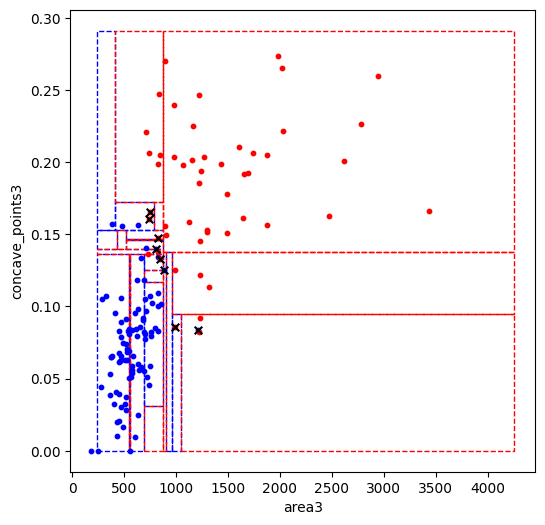

In [6]:


fig, ax = plt.subplots(1,1, figsize = (6,6))
for r in range(rule_limits.shape[0]):
    if r<changeclsidx-1:
        ax.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=1, edgecolor='blue', linestyle='--', facecolor='none'))
    else:
        ax.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=1, edgecolor='red', linestyle='--', facecolor='none'))
        
ax.scatter(X_calib["area3"][y_calib == 0], X_calib["concave_points3"][y_calib == 0], c = "blue", s = 10, marker = 'o')
ax.scatter(X_calib["area3"][y_calib == 1], X_calib["concave_points3"][y_calib == 1], c = "red", s = 10, marker = 'o')
ax.scatter(wrong_0[:, 0], wrong_0[:, 1], c="black", s=30, marker='x')
ax.scatter(wrong_1[:, 0], wrong_1[:, 1], c="black", s=30, marker='x')
plt.xlabel("area3")
plt.ylabel("concave_points3")
plt.show()

In [7]:
# decision tree with m-estimate probabilities (see Eq. 9)

def m_estimate_proba(model, X, y_train, m = 0.0):
    '''
    n_c: number of instances from class j that fall in the same leaf as instance i
    m: parameter in [0,inf] --> larger smoother
    p_cj: prior probability for class j
    '''
    dt_tree = model.tree_

    #y_train = model.classes_ 
    class_counts = np.bincount(y_train)
    p_c = class_counts / class_counts.sum()
    idx_leaves = model.apply(X)
    probabilities = []
    for node in idx_leaves:
        # Get counts for this leaf
        n_c = dt_tree.value[node][0] # raw counts per class
        n = n_c.sum()
        # m-estimate
        p = (n_c + m * p_c) / (n + m)
        probabilities.append(p)

    return np.vstack(probabilities)

#m_prob = m_estimate_proba(model, X_test.iloc[:, top2_idx], y_train, m = 2.0)
#print(m_prob)
    

In [8]:
def margin_based_score(model, X, y_train, y, mode = "standard"):
    if mode == "standard":
        pr = model.predict_proba(X)
    elif mode == "m-estimate":
        pr = m_estimate_proba(model, X, y_train, m = 2.0)
    #print(pr)
    if y == 0:
        score = pr[:,0] - pr[:,1]
    elif y == 1:
        score = pr[:, 1] - pr[:,0]
    return -score # use - to get a nonconformity


def vanilla_score(model, X, y):
    pr = model.predict_proba(X)
    #print(pr)
    if y == 0:
        score = 1 - pr[:, 0]
    elif y == 1:
        score = 1 - pr[:, 1]
    return score 

def GetPredictionRegions(y_calib, scores0, scores1, scores0ts, scores1ts, epsilon, n_c):

    scores_calib = np.where(y_calib == 0, scores0, scores1)

    scores_calib_sorted = np.sort(scores_calib)


    qlevel = np.ceil((n_c + 1) * (1 - epsilon)) / n_c
    s_epsilon = np.quantile(scores_calib_sorted, qlevel)

    n_test = scores0ts.shape[0]
    C_all = np.full(n_test, np.nan)
    C_size = np.full(n_test, np.nan)

    for r in range(n_test):
        tau0_r = scores0ts[r]
        tau1_r = scores1ts[r]
        if tau0_r <= s_epsilon and tau1_r > s_epsilon:
            C_all[r] = 0
            C_size[r] = 1
        elif tau0_r > s_epsilon and tau1_r <= s_epsilon:
            C_all[r] = 1
            C_size[r] = 1
        elif tau0_r <= s_epsilon and tau1_r <= s_epsilon:
            C_all[r] = 2
            C_size[r] = 2
        elif tau0_r > s_epsilon and tau1_r > s_epsilon:
            C_all[r] = 3
            C_size[r] = 0
        else:
            continue   
    return C_all, s_epsilon, scores_calib, C_size

scores0 = margin_based_score(model, X_calib2, y_train, 0, mode = "m-estimate")
scores1 = margin_based_score(model, X_calib2, y_train, 1, mode = "m-estimate")

scores0ts = margin_based_score(model, X_test.iloc[:,top2_idx], y_train, 0, mode = "m-estimate")
scores1ts = margin_based_score(model, X_test.iloc[:,top2_idx], y_train, 1, mode = "m-estimate")


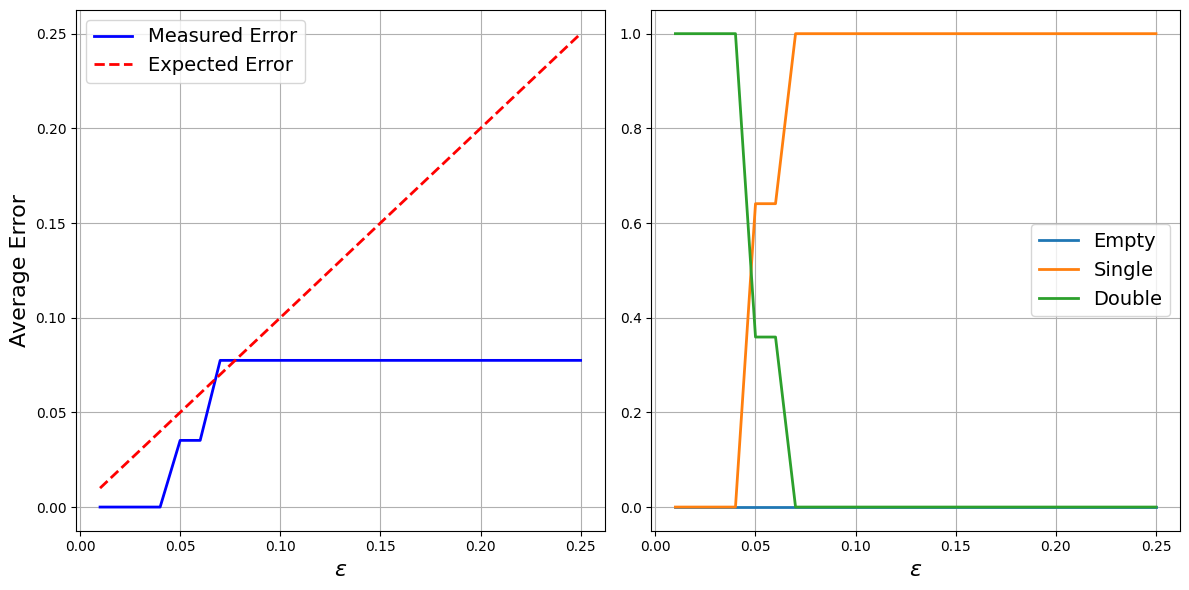

In [ ]:

epsilonrange = np.linspace(0.01, 0.25, 25)
n_eps = len(epsilonrange)

avgErr = np.zeros(n_eps)
empty = np.zeros(n_eps)
singleton = np.zeros(n_eps)
double = np.zeros(n_eps)

avgSize = np.zeros(n_eps)
for i, epsilon in enumerate(epsilonrange):
    # Compute prediction regions
    C_all, s_epsilon, selectedscores, C_size = GetPredictionRegions(y_calib, scores0, scores1, scores0ts, scores1ts, epsilon, len(X_calib2))
    
    n_err = np.sum((y_test != C_all) & (C_all != 2))
    avgErr[i] = n_err / len(X_test)
    
    empty[i] = np.sum(C_size == 0) / len(X_test)
    singleton[i] = np.sum(C_size == 1) / len(X_test)
    double[i] = np.sum(C_size == 2) / len(X_test)
    avgSize[i] = np.sum(C_size)/len(X_test)

# Plot with subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))


axs[0].plot(epsilonrange, avgErr, 'b', linewidth=2, label='Measured Error')
axs[0].plot(epsilonrange, epsilonrange, 'r--', linewidth=2, label='Expected Error')
axs[0].set_xlabel(r'$\varepsilon$', fontsize=16)
axs[0].set_ylabel("Average Error", fontsize=16)
axs[0].legend(fontsize=14)
axs[0].grid(True)


axs[1].plot(epsilonrange, empty, linewidth=2, label='Empty')
axs[1].plot(epsilonrange, singleton, linewidth=2, label='Single')
axs[1].plot(epsilonrange, double, linewidth=2, label='Double')
#axs[1].plot(epsilonrange, avgSize, linewidth=2, label='AvgSize')
axs[1].set_xlabel(r'$\varepsilon$', fontsize=16)
#axs[1].set_ylabel("%", fontsize=16)
axs[1].legend(fontsize=14)
axs[1].grid(True)

plt.tight_layout()
#if save_plots_flag:
#    plt.savefig(res_path+"plots/CP_metrics.png", dpi = 200, bbox_inches="tight")
plt.show()

In [27]:
predsets = {}
size = {}
for eps in [0.01, 0.05, 0.1, 0.2]:
    C_all, _, _, C_size = GetPredictionRegions(y_calib, scores0, scores1, scores0ts, scores1ts, eps, len(X_calib2))
    predsets[eps]=C_all
    size[eps] = C_size

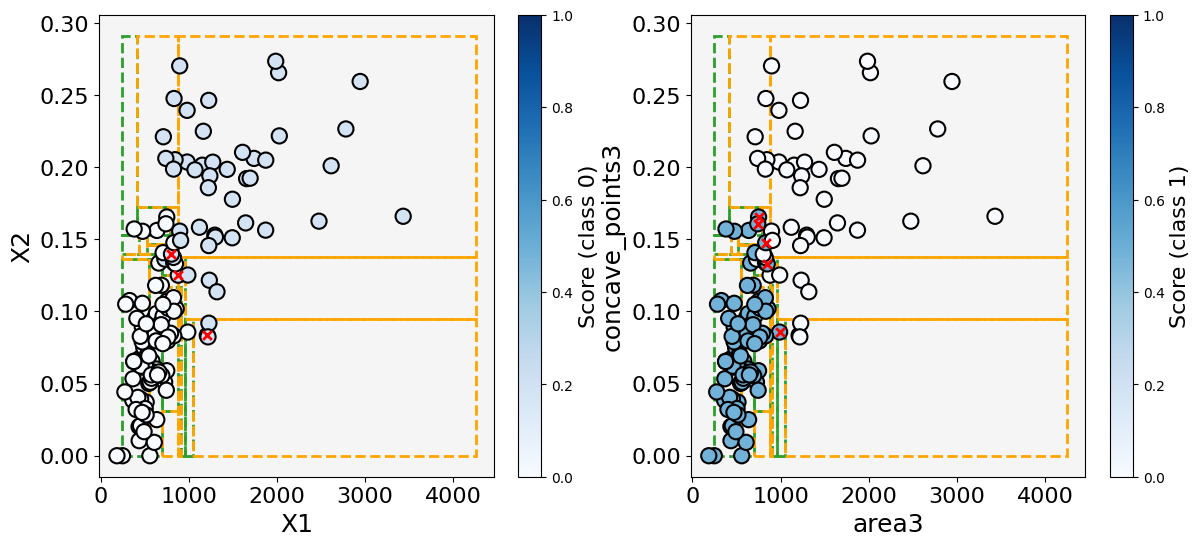

In [ ]:
from matplotlib import colors

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))
norm = colors.Normalize(vmin=0, vmax=1) 
for r in range(rule_limits.shape[0]):
    if r<changeclsidx-1:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange',linestyle='--', facecolor='none'))

#sc = ax1.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores0, s=50, cmap='jet', marker='o', norm = norm)
#ax1.scatter(wrong_1[:, 0], wrong_1[:, 1], c="white", s=20, marker='x')
sc = ax1.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores0, cmap='Blues', norm=norm, s=120, edgecolors='black', linewidth=1.5, marker='o')
ax1.scatter(wrong_1[:,0], wrong_1[:,1], c='red', s=40, marker='x', linewidth=2)


cbar = plt.colorbar(sc, ax=ax1)
#cbar.set_label('Score (class 0)', fontsize=16)
    #cbar.set_ticks([0, 1])
    #cbar.set_ticklabels(['0.0', '1.0'])
ax1.set_facecolor("whitesmoke")
ax1.set_xlabel("area3", fontsize=18)
ax1.set_ylabel("concave_points3", fontsize=18)
ax1.tick_params(labelsize=16)


#sc = ax2.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores1, s=50, cmap='jet', marker='o', norm = norm)
#ax2.scatter(wrong_0[:, 0], wrong_0[:, 1], c="magenta", s=20, marker='x')
sc = ax2.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores1, cmap='Blues', norm=norm, s=120, edgecolors='black', linewidth=1.5, marker='o')
ax2.scatter(wrong_0[:,0], wrong_0[:,1], c='red', s=40, marker='x', linewidth=2)


cbar = plt.colorbar(sc, ax=ax2)
#cbar.set_label('Score (class 1)', fontsize=16)

ax2.set_xlabel("area3", fontsize=18)
ax2.set_ylabel("concave_points3", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.set_facecolor("whitesmoke")
#fig.suptitle("Margin-based score", fontsize = 18)
#if save_plots_flag:
#    plt.savefig(res_path+"plots/calibration_scores_margin.png", dpi = 200, bbox_inches="tight")
plt.show()

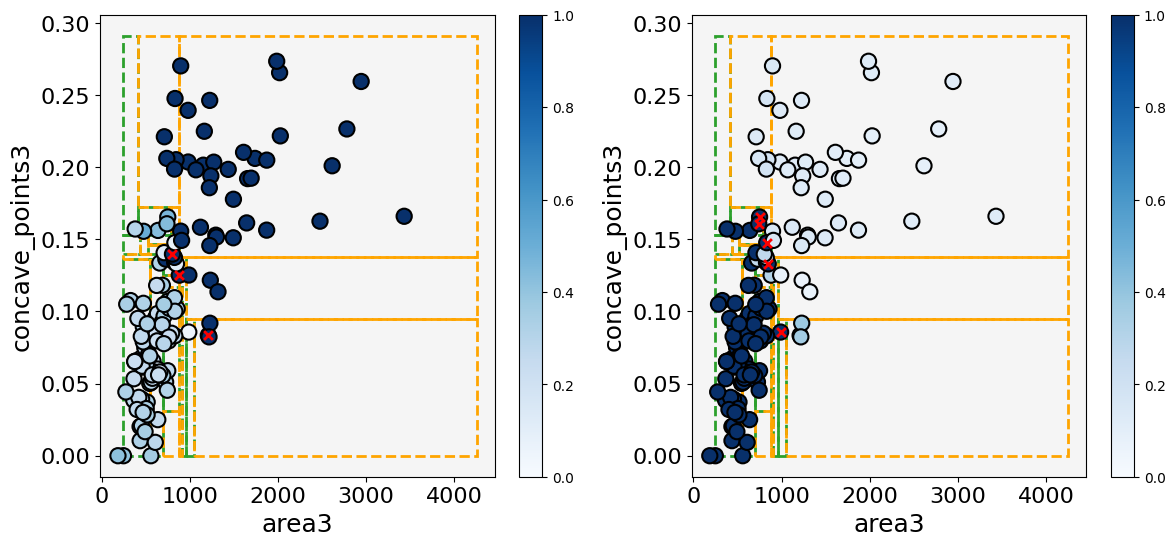

In [24]:
# same plot for our method

from matplotlib import colors

confiderai_res = pd.read_excel("test_dt_GIoU_PrunOff_2d/scores_calib_breastW2d.xlsx")
scores0conf = confiderai_res["score-0"].values
scores1conf = confiderai_res["score-1"].values

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))
norm = colors.Normalize(vmin=0, vmax=1) 
for r in range(rule_limits.shape[0]):
    if r<changeclsidx-1:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='tab:green', linestyle='--', facecolor='none'))
    else:
        ax1.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange', linestyle='--', facecolor='none'))
        ax2.add_patch(plt.Rectangle((rule_limits[r,0], rule_limits[r,2]), abs(rule_limits[r,1]-rule_limits[r,0]), abs(rule_limits[r,3]-rule_limits[r,2]), linewidth=2, edgecolor='orange',linestyle='--', facecolor='none'))

#sc = ax1.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores0conf, s=50, cmap='jet', marker='o', norm = norm)
#ax1.scatter(wrong_1[:, 0], wrong_1[:, 1], c="white", s=20, marker='x')
sc = ax1.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores0conf, cmap='Blues', norm=norm, s=120, edgecolors='black', linewidth=1.5, marker='o')
ax1.scatter(wrong_1[:,0], wrong_1[:,1], c='red', s=40, marker='x', linewidth=2)

cbar = plt.colorbar(sc, ax=ax1)
#cbar.set_label('Score (class 0)', fontsize=16)
    #cbar.set_ticks([0, 1])
    #cbar.set_ticklabels(['0.0', '1.0'])
ax1.set_facecolor("whitesmoke")
ax1.set_xlabel("area3", fontsize=18)
ax1.set_ylabel("concave_points3", fontsize=18)
ax1.tick_params(labelsize=16)


#sc = ax2.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores1conf, s=50, cmap='jet', marker='o', norm = norm)
#ax2.scatter(wrong_0[:, 0], wrong_0[:, 1], c="white", s=20, marker='x')
sc = ax2.scatter(X_calib2.values[:, 0], X_calib2.values[:, 1], c=scores1conf, cmap='Blues', norm=norm, s=120, edgecolors='black', linewidth=1.5, marker='o')
ax2.scatter(wrong_0[:,0], wrong_0[:,1], c='red', s=40, marker='x', linewidth=2)

cbar = plt.colorbar(sc, ax=ax2)
#cbar.set_label('Score (class 1)', fontsize=16)
ax2.set_facecolor("whitesmoke")
ax2.set_xlabel("area3", fontsize=18)
ax2.set_ylabel("concave_points3", fontsize=18)
ax2.tick_params(labelsize=16)
#fig.suptitle("Margin-based score", fontsize = 18)
#if save_plots_flag:
#    plt.savefig(res_path+"plots/calibration_scores_margin.png", dpi = 200, bbox_inches="tight")
plt.show()

In [ ]:
# TODO: confrontare numericamente i valori degli score sui punti "wrong" e le relative prediction region

print(scores0[idx_wrong_1])
print(scores1[idx_wrong_0])
print(scores0conf[idx_wrong_1])
print(scores1conf[idx_wrong_0])


[0.18596491 0.18596491 0.18596491]
[0.48070175 0.48070175 0.48070175 0.48070175 0.48070175]
[1. 1. 1.]
[1. 1. 1. 1. 1.]
